In [16]:
class AddLayer:
  def __init__(self):
    pass

  def foward(self, x,y):
    out = x + y
    return out

  def backward(self, dout):
    dx = dout * 1
    dy = dout * 1

    return dx, dy

In [17]:
class MulLayer:
  def __init__(self): # initialize x and y
    self.x = None
    self.y = None

  def foward(self, x, y):
    self.x = x
    self.y = y
    out = x * y

    return out

  def backward(self, dout):
    dx = dout * self.y # 곱셈 노드에서 역전파는 x 와 y를 스위칭 하여 이전 입력 신호에 곱하여 다음 노드로 전달 한다.

    dy = dout * self.x

    return dx, dy

In [18]:
from numpy import exp
class SigLayer:
  def __init__(self):
    self.out = None

  def foward(self, x):
    out = 1 / (1 + exp(-x))
    self.out = out
    return out

  def backward(self, dout):
    dx = dout * self.out * (1 - self.out)
    return dx

In [19]:
class ReluLayer:
  def __inut__(self):
    self.mask = None

  def foward(self, x):
    self.mask = (x >= 0)
    if self.mask: out = x
    else: out = 0.1 * x
    return out

  def backward(self, dout):
    if self.mask: dx = dout
    else: dx = dout * 0.1
    return dx

In [20]:
def StepFunction (x):
  if x <= 0.33:
    out = 0
  elif x >= 0.33 and x <= 0.66:
    out = 1
  else:
    out = 2
  return out

In [21]:
!pip install numpy==1.23.0

  Using cached numpy-1.23.0.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


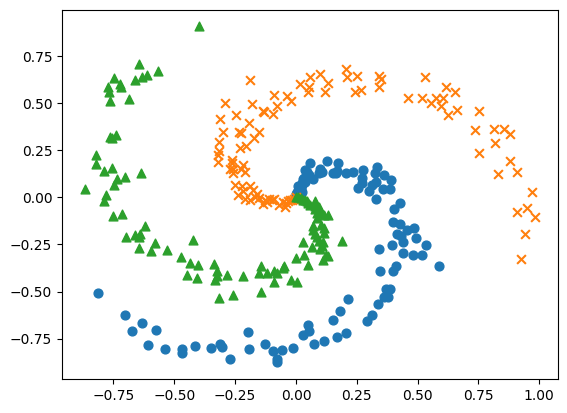

In [22]:
import numpy as np
import matplotlib.pyplot as plt
def load_spiral_data(seed=7777):
    np.random.seed(seed)
    DIM = 2  # 입력 데이터 특성 수
    CLS_NUM = 3  # 분류할 클래스 수
    N = 100  # 클래스 하나 당 샘플 데이터 수
    x = np.zeros((N*CLS_NUM, DIM))
    t = np.zeros((N*CLS_NUM, CLS_NUM), dtype=int)
    for j in range(CLS_NUM):
        for i in range(N): # N*j, N*(j+1)):
            rate = i / N
            radius = 1.0*rate
            theta = j*4.0 + 4.0*rate + np.random.randn()*0.2
            ix = N*j + i
            x[ix] = np.array([radius*np.sin(theta),
                              radius*np.cos(theta)]).flatten()
            t[ix, j] = 1
    return x, t
x, t = load_spiral_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()

In [23]:
import random
RealLoss = 96
L = 0
best = [-6.599258732443065, -11.670613908538233, 0.08171154383785116, -17.780868042618742, 13.133805071984698, -3.911233291002836, 11.618469239812594, 20.12287261682691, 0.6642157467747792, -13.025070871179505, -7.9386179605754945, 14.602022113784807, -5.167251096153208]
x1 = None
w1, w3, w7 = 0, 0, 0
mul1 = MulLayer()
mul2 = MulLayer()
add5 = AddLayer()

x2 = None
w2, w4, w8 = 0, 0, 0
mul3 = MulLayer()
mul4 = MulLayer()
add6 = AddLayer()

#u1 = x1*w1 + x2*w2 + b1
b1 = 0
rel7 = ReluLayer()
#h1 = rel(u1)
w5 = 0
mul9 = MulLayer()

#u2 = x1*w3 + x2*w4 + b2
b2 = 0
rel8 = ReluLayer()
#h2 = rel(u2)
w6 = 0
mul10 = MulLayer()

#u3 = x1*w7 + x2*w8 +b4
b4 = 0
rel13 = ReluLayer()
#h3 = rel(u3)
w9 = 0
mul14 = MulLayer()

mul12 = MulLayer()
add11 = AddLayer()
#o1 = h1*w5 + h2*w6 + h3*w9 + b3
sig12 = SigLayer()
#y = sig(o1)

arr = []
for i in range(13):
  arr.append(random.uniform(-2, 2))
w1, w2, w3, w4, w5, w6, w7, w8, w9, b1, b2, b3, b4 = arr

rel0 = ReluLayer()
def predict(arr):
  score = np.array([])
  global RealLoss, best, w1, w2, w3, w4, w5, w6, w7, w8, w9, b1, b2, b3, b4
  for index in range(len(arr)):
    x1 = arr[index][0]
    x2 = arr[index][1]
    a = (x1*w1 + x2*w2 + b1)
    b = (x1*w3 + x2*w4 + b2)
    c = (x1*w7 + x2*w8 + b4)
    aa = rel0.foward(a)
    bb = rel0.foward(b)
    cc = rel0.foward(c)
    res = (w5*aa + w6*bb + w9*cc + b3)
    score = np.append(score, StepFunction(1/(1+exp(-res))))
  if (len(score) == len(t)):
    L = sum(((t.argmax(axis = 1) - score)**2))
    print(L)
    if (L < RealLoss):
      RealLoss = L
      best = [w1, w2, w3, w4, w5, w6, w7, w8, w9, b1, b2, b3, b4]
      print("best 갱신")
    #else:
      #w1, w2, w3, w4, w5, w6, w7, w8, w9, b1, b2, b3, b4 = best
  return score

lr = 1
for i in range(3000):
  idx = np.random.permutation(len(x))
  epoch = 0
  for idx in idx:
    epoch += 1
    x1 = x[idx][0]
    x2 = x[idx][1]
    label = t.argmax(axis = 1)[idx]

      #u1 = add5.foward(mul1.foward(x1, w1), mul2.foward(x1, w3)) + b1
      #u2 = add6.foward(mul3.foward(x2, w2), mul4.foward(x2, w4)) + b2
      #u1 = add5.foward(mul1.foward(x1, w1), mul3.foward(x1, w3)) + b1
      #u2 = add6.foward(mul2.foward(x2, w2), mul4.foward(x2, w4)) + b2
    u1 = add5.foward(mul1.foward(x1, w1), mul2.foward(x2, w2)) + b1
    u2 = add6.foward(mul3.foward(x1, w3), mul4.foward(x2, w4)) + b2
    u3 = mul9.foward(x1, w7) + mul10.foward(x2, w8) + b4
    h1 = rel7.foward(u1)
    h2 = rel8.foward(u2)
    h3 = rel13.foward(u3)
    o1 = mul9.foward(h1, w5) + mul10.foward(h2, w6) + mul14.foward(h3, w9) + b3 #add11
    y = sig12.foward(o1)
    result = StepFunction(y)
    loss = (label - result)**2

      # loss y로 미분한 값(dloss/dy)
    dloss = -(label/2 - y)

    dout = sig12.backward(dloss) # dout = dloss/dy * dy/do1
    b3 -= lr * dout
    dout1, dout2, dout3 = dout, dout, dout
    dout3, dw9 = mul14.backward(dout3) # dout2 = dloss/dy * dy/do1 * do1/dh2, dw6 = dloss/dy * dy/do1 * do1/dw6
    dout2, dw6 = mul10.backward(dout2) # dout2 = dloss/dy * dy/do1 * do1/dh2, dw6 = dloss/dy * dy/do1 * do1/dw6
    dout1, dw5 = mul9.backward(dout1) # dout1 = dloss/dy * dy/do1 * do1/dh1, dw5 = dloss/dy * dy/do1 * do1/dw5
      ## b2 -= dout2
      ## b1 -= dout1
    w6 -= lr * dw6
    w5 -= lr * dw5
    w9 -= lr * dw9
    dout3 = rel13.backward(dout3) # dout2 = dloss/dy * dy/do1 * do1/dh2 * dh2/du2
    dout2 = rel8.backward(dout2) # dout2 = dloss/dy * dy/do1 * do1/dh2 * dh2/du2
    dout1 = rel7.backward(dout1) # dout1 = dloss/dy * dy/do1 * do1/dh1 * dh1/du1
    b4 -= lr * dout3
    b2 -= lr * dout2
    b1 -= lr * dout1
    dw8 = mul10.backward(dout3)[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw8
    dw7 = mul9.backward(dout3)[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw7
    dw4 = mul4.backward(add6.backward(dout2)[1])[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw4
      # add6.backward(dout2)[0~1] = dout2
    dw3 = mul3.backward(add6.backward(dout2)[0])[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw3
    dw2 = mul2.backward(add5.backward(dout1)[1])[1] # dloss/dy * dy/do1 * do1/dh1 * dh1/du1 * du1/dw2
       # add5.backward(dout1)[0~1] = dout1
    dw1 = mul1.backward(add5.backward(dout1)[0])[1] # dloss/dy * dy/do1 * do1/dh1 * dh1/du1 * du1/dw1
    w8 -= lr * dw8
    w7 -= lr * dw7
    w4 -= lr * dw4
    w3 -= lr * dw3
    w2 -= lr * dw2
    w1 -= lr * dw1
    if (epoch==300 and i%100 == 0):
      print(i, predict(x))
      print(w1, w2, w3, w4, w5, w6)

200.0
0 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0.2930060149223857 -0.7417353838823577 -0.3218354052042059 -0.0377231616158213

/tmp/ipykernel_7392/2251347459.py:7: RuntimeWarning: overflow encountered in exp
  out = 1 / (1 + exp(-x))


208.0
1800 [2. 2. 2. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 2. 0. 2. 0. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 0. 2. 2. 2. 0. 2. 0. 2. 2. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 2. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 2. 2. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 2. 0.
 0. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
25.113137940616806 -27.817640176799138 16.595960593637876 -28.6126799696979

/tmp/ipykernel_7392/1277651260.py:63: RuntimeWarning: overflow encountered in exp
  score = np.append(score, StepFunction(1/(1+exp(-res))))


591.0
1900 [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 0. 0. 2. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 2. 0. 2. 0. 0. 2. 0. 2. 2. 0. 2. 2. 2. 2. 2. 2. 0. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0.
 2. 2. 0. 0. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
25.773883791571656 -30.131305476314783 17.35539379905744 -28.05873271735338

In [24]:
print(best)
#best = [-0.8707099786523608, -20.155910205723625, -4.432801187828633, -8.07977446138271, -3.486526603579847, 2.2355263288807707, -8.518623065541401, 1.1701836484226134, -5.769683298235072]
w1, w2, w3, w4, w5, w6, w7, w8, w9, b1, b2, b3, b4 = best
predict(x)

[-6.599258732443065, -11.670613908538233, 0.08171154383785116, -17.780868042618742, 13.133805071984698, -3.911233291002836, 11.618469239812594, 20.12287261682691, 0.6642157467747792, -13.025070871179505, -7.9386179605754945, 14.602022113784807, -5.167251096153208]
96.0


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 1., 1.,
       1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1.,
       1., 2., 0., 2., 2., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 2., 1.,
       2., 2., 2., 2., 2.

(397, 411)
(163167, 2)
(163167,)


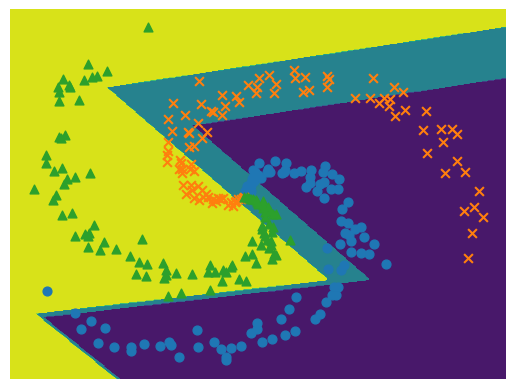

In [25]:
# 경계 영역 플롯
h = 0.005
x_min, x_max = x[:, 0].min() - .1, x[:, 0].max() + .1
y_min, y_max = x[:, 1].min() - .1, x[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
print(xx.shape)
X = np.c_[xx.ravel(), yy.ravel()]
print(X.shape)
score = predict(X)
print(score.shape)
Z = score.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')
# 데이터점 플롯
x, t = load_spiral_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()